# Pokémon Battle Prediction

This notebook presents our submission to the **2025 Pokémon Battle Prediction Challenge**, organized as part of the *Foundations of Data Science* course in the MSc programs in Computer Science and Data Science at Sapienza University of Rome.

## The challenge

The goal is to train a binary classifier that predicts the **winner of a Pokémon battle** from the perspective of **Player 1**. The data come from real human-versus-human matches played on the Pokémon Showdown simulator in the **Generation 1 OverUsed (OU)** competitive format.

Each battle contains three main sources of information:

- **Player 1's initial team:** the six Pokémon selected by Player 1, including names, levels, types, and base statistics.
- **Player 2's known lead:** the first Pokémon revealed by Player 2 and its corresponding attributes.
- **Battle timeline:** a turn-by-turn description of the first 30 active turns, including the active Pokémon, remaining HP, status conditions, field effects, stat boosts, and moves used by both players.

The target variable, `player_won`, is `True` when Player 1 wins and `False` otherwise. Submissions are evaluated using **classification accuracy**.

>***The challenge must be solved exclusively through feature engineering and classical machine-learning models. Neural networks and other deep-learning approaches are not allowed.***

## Our approach

We create a tabular representation that combines team composition, base statistics, battle-state summaries, status conditions, switching behavior, remaining resources, speed, and historical one-on-one matchup statistics. We then tune a Random Forest and an XGBoost classifier and combine them with a scaled Logistic Regression model in a stacking ensemble.

To obtain a more reliable estimate of generalization performance, model selection and evaluation use grouped cross-validation based on `battle_id`. The final ensemble is trained on all available labeled battles and used to produce `submission.csv`.

> **Reproducibility note:** the notebook expects `train.jsonl` and `test.jsonl` under `../input/competitions/fds-pokemon-battles-prediction-2025/`. Update `DATA_PATH` if the files are stored elsewhere.

> **Execution note:** saved outputs have been cleared so that the published notebook does not display stale results. Run all cells from top to bottom to reproduce the feature matrices, validation scores, and submission file.

## 1. Setup and data loading

We begin by importing the libraries used for data manipulation, model selection, and evaluation. The training data are stored in JSON Lines format, with one battle per line. After loading the file, we display a shortened example to make the nested schema easier to inspect without printing an entire timeline.

In [74]:
import json
import os
from time import perf_counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupKFold, KFold, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

from xgboost import XGBClassifier
from scipy.stats import randint, uniform



### Dataset location and schema preview

The following cell defines the expected dataset location, loads the labeled battles, and prints a compact example of the nested JSON structure. Keeping path configuration separate from imports makes the notebook easier to adapt to another environment.

In [75]:
COMPETITION_NAME = 'fds-pokemon-battles-prediction-2025'
DATA_PATH = os.path.join('../input/competitions', COMPETITION_NAME)

train_file_path = os.path.join(DATA_PATH, 'train.jsonl')
test_file_path = os.path.join(DATA_PATH, 'test.jsonl')

train_data = []

print(f"Loading data from '{train_file_path}'...")
try:
    with open(train_file_path, 'r') as f:
        for line in f:
            train_data.append(json.loads(line))

    print(f"Successfully loaded {len(train_data)} battles.")

    # Inspect the first battle to see its structure
    print("\n--- Structure of the first train battle: ---")
    if train_data:
        first_battle = train_data[0]
        battle_for_display = first_battle.copy()

        # Show only the first turn for readability
        battle_for_display['battle_timeline'] = battle_for_display.get('battle_timeline', [])[:1]
        print(json.dumps(battle_for_display, indent=4))
        if len(first_battle.get('battle_timeline', [])) > 3:
            print("    ...")
            print("    (battle_timeline has been truncated for display)")

except FileNotFoundError:
    print(f"ERROR: Could not find the training file at '{train_file_path}'.")
    print("Please make sure you have added the competition data to this notebook.")


Loading data from '../input/competitions/fds-pokemon-battles-prediction-2025/train.jsonl'...
Successfully loaded 10000 battles.

--- Structure of the first train battle: ---
{
    "player_won": true,
    "p1_team_details": [
        {
            "name": "starmie",
            "level": 100,
            "types": [
                "psychic",
                "water"
            ],
            "base_hp": 60,
            "base_atk": 75,
            "base_def": 85,
            "base_spa": 100,
            "base_spd": 100,
            "base_spe": 115
        },
        {
            "name": "exeggutor",
            "level": 100,
            "types": [
                "grass",
                "psychic"
            ],
            "base_hp": 95,
            "base_atk": 95,
            "base_def": 85,
            "base_spa": 125,
            "base_spd": 125,
            "base_spe": 55
        },
        {
            "name": "chansey",
            "level": 100,
            "types": [
            

## 2. Feature-engineering utilities

The raw data combine static team information with a sequential battle log. The helper functions below provide the building blocks needed to turn those nested records into numerical features.

In particular, they:

- collect reusable Pokémon metadata and base statistics;
- adjust effective Speed when a Pokémon is paralyzed;
- divide each battle timeline into contiguous one-on-one encounters;
- summarize HP loss, knockouts, switches, status conditions, and encounter duration;
- make matchup statistics less dependent on which player occupied a given side.

These utilities are deliberately separated from the main extraction function so that each transformation remains easier to inspect and reuse.

In [76]:
# Feature Extraction Helpers 

from collections import defaultdict

POKEMON_STATS = ["hp", "atk", "def", "spa", "spd", "spe"]
POKEMON_TYPES = [
    "normal", "fire", "water", "electric", "grass", "ice", "fighting", "poison",
    "ground", "flying", "psychic", "bug", "rock", "ghost", "dragon"
]


# Basic Pokémon info extraction
def extract_pokemon_info(data):
    info = {}
    for battle in data:
        for p in battle.get("p1_team_details", []):
            name = p.get("name")
            if name and name not in info:
                info[name] = p
    return info


# Effective speed (status-aware)
def effective_speed(mon):
    base = mon.get("info", {}).get("base_spe", 0)
    if mon.get("status") == "par":
        return base / 4.0
    return base


# Encounter Extraction 

def _state(turn, side):
    """Extract safe state dict from a timeline turn."""
    st = turn.get(side, {}) or {}
    return {
        "name": st.get("name"),
        "hp": st.get("hp_pct", 0.0) or 0.0,
        "status": st.get("status", "nostatus") or "nostatus",
    }


def extract_encounters_from_battle(battle):
    """
    Split a battle's timeline into contiguous 1v1 encounters:
    A 1v1 encounter is a maximal consecutive block of turns where
    (p1_pokemon_name, p2_pokemon_name) does not change.
    """
    tl = battle.get("battle_timeline", [])
    if not tl:
        return []

    enc = []

    first = tl[0]
    s1 = _state(first, "p1_pokemon_state")
    s2 = _state(first, "p2_pokemon_state")

    cur1 = s1["name"]
    cur2 = s2["name"]
    if cur1 is None or cur2 is None:
        return []

  
    last_s1 = s1
    last_s2 = s2
    start_idx = 0
    for idx, turn in enumerate(tl):
        s1 = _state(turn, "p1_pokemon_state")
        s2 = _state(turn, "p2_pokemon_state")

        last_encounter_over = True 

        if last_encounter_over:
            hp1_start = s1["hp"]
            hp2_start = s2["hp"]
            status1_start = s1["status"]
            status2_start  = s2["status"]
        if idx > 0 and (s1["name"] != cur1 or s2["name"] != cur2):
            # close old encounter
            turns = idx - start_idx
            hp1_end = last_s1["hp"]
            hp2_end = last_s2["hp"]
            status1_end = last_s1["status"]
            status2_end = last_s2["status"]
            a_dead = (hp1_end <= 0) or (status1_end == "fnt")
            b_dead = (hp2_end <= 0) or (status2_end == "fnt")
            enc.append({
                "p1_name": cur1.lower(),
                "p2_name": cur2.lower(),
                "hp1_start": hp1_start,
                "hp1_end": hp1_end,
                "hp1_diff": hp1_start - hp1_end,
                "hp2_start": hp2_start,
                "hp2_end": hp2_end,
                "hp2_diff": hp2_start - hp2_end,
                "inflicted_status1": status1_end if status1_end != "fnt" and status1_end != status1_start else None,
                "inflicted_status2": status2_end if status2_end != "fnt" and status2_end != status2_start else None,
                "turns": turns,
                "a_switched": (s1["name"] != cur1) and not a_dead,
                "b_switched": (s2["name"] != cur2) and not b_dead,
                "status1_end" : status1_end,
                "status2_end" : status2_end,
            })

            # start new encounter
            cur1 = s1["name"]
            cur2 = s2["name"]
            hp1_start = s1["hp"]
            hp2_start = s2["hp"]
            start_idx = idx
            last_encounter_over = True

        last_s1 = s1
        last_s2 = s2

    # close last encounter
    turns = len(tl) - start_idx
    hp1_end = last_s1["hp"]
    hp2_end = last_s2["hp"]
    status1_end = last_s1["status"]
    status2_end = last_s2["status"]
    enc.append({
        "p1_name": cur1.lower(),
        "p2_name": cur2.lower(),
        "hp1_start": hp1_start,
        "hp1_end": hp1_end,
        "hp1_diff": hp1_start - hp1_end,
        "hp2_start": hp2_start,
        "hp2_end": hp2_end,
        "hp2_diff": hp2_start - hp2_end,
        "inflicted_status1": status1_end if status1_end != "fnt" and status1_end != status1_start else None,
        "inflicted_status2": status2_end if status2_end != "fnt" and status2_end != status2_start else None,
        "turns": turns,
        "a_switched": False,
        "b_switched": False,
        "status1_end" : status1_end,
        "status2_end" : status2_end,
    })

    return enc


def get_symmetrized_row(row1, row2):

    out = {}
    for key in row1:
        if key[-1] == "a":
            symmetric_key = key[:-1] + "b"
            out[key] = row1[key] + row2[symmetric_key]
        elif key in ["average_delta_hp", "switch_rate_difference"]:
            out[key] = row1[key] - row2[key]
        else:
            out[key] = row1[key] + row2[key]
        out[key] = out[key]/2
    return out

# Build Global Matchup Stats 

def build_matchup_stats(data):
    raw = defaultdict(lambda: {
        "count": 0, "a_ko": 0, "b_ko": 0,
        "a_switch": 0, "b_switch": 0,
        "sum_turns": 0.0,
        "sum_hp1_start": 0.0, "sum_hp1_end": 0.0, "sum_hp1_diff": 0.0, "sum_hp2_diff": 0.0, 
        "sum_inflicted_frz_1": 0.0, "sum_inflicted_slp_1": 0.0, "sum_inflicted_psn_1": 0.0, "sum_inflicted_brn_1": 0.0,
        "sum_inflicted_frz_2": 0.0, "sum_inflicted_slp_2": 0.0, "sum_inflicted_psn_2": 0.0, "sum_inflicted_brn_2": 0.0,
        "sum_hp2_start": 0.0, "sum_hp2_end": 0.0
    })

    for battle in data:
        for enc in extract_encounters_from_battle(battle):
            a = enc["p1_name"]
            b = enc["p2_name"]
            if not a or not b:
                continue
            bucket = raw[(a, b)]
            bucket["count"] += 1
            bucket["sum_turns"] += enc["turns"]
            bucket["sum_hp1_start"] += enc["hp1_start"]
            bucket["sum_hp1_end"] += enc["hp1_end"]
            bucket["sum_hp2_start"] += enc["hp2_start"]
            bucket["sum_hp2_end"] += enc["hp2_end"]
            bucket["sum_hp1_diff"] += enc["hp1_diff"]
            bucket["sum_hp2_diff"] += enc["hp2_diff"]
            if enc["inflicted_status1"] in ["slp","frz","brn","psn"]:
                bucket[f"sum_inflicted_{enc['inflicted_status1']}_1"] += 1
            
            if enc["inflicted_status2"] in ["slp","frz","brn","psn"]:
                bucket[f"sum_inflicted_{enc['inflicted_status2']}_2"] += 1

            a_dead = (enc["hp1_end"] <= 0) or (enc["status1_end"] == "fnt")
            b_dead = (enc["hp2_end"] <= 0) or (enc["status2_end"] == "fnt")

            if a_dead and not b_dead:
                bucket["b_ko"] += 1
            elif b_dead and not a_dead:
                bucket["a_ko"] += 1

            if enc["a_switched"]:
                bucket["a_switch"] += 1
            if enc["b_switched"]:
                bucket["b_switch"] += 1

    # normalize - MATCHUP_STATS
    stats = {}
    for (a, b), bk in raw.items():
        c = bk["count"]
        if c == 0:
            continue

        win_a = bk["a_ko"] / c
        win_b = bk["b_ko"] / c
        avg_turns = bk["sum_turns"] / c

        hp1_s = bk["sum_hp1_start"] / c
        hp1_e = bk["sum_hp1_end"] / c
        hp2_s = bk["sum_hp2_start"] / c
        hp2_e = bk["sum_hp2_end"] / c
        hp1_d = bk["sum_hp1_diff"] / c
        hp2_d = bk["sum_hp2_diff"] / c

        stats[(a, b)] = {
            "count": c,
            "winrate_a": win_a,
            "winrate_b": win_b,
            "avg_turns": avg_turns,
            "avg_delta_hp_a": hp1_e - hp1_s,
            "avg_delta_hp_b": hp2_e - hp2_s,
            "avg_final_hp_diff": hp1_e - hp2_e,
            "avg_delta_hp_with_diff_a": hp1_d,
            "avg_delta_hp_with_diff_b": hp2_d,
            "avg_delta_hp": hp1_d - hp2_d,
            "switch_rate_a": bk["a_switch"] / c,
            "switch_rate_b": bk["b_switch"] / c,
            "switch_rate_difference": bk["b_switch"] / c - bk["a_switch"] / c, 
            "avg_frz_a": bk["sum_inflicted_frz_1"],
            "avg_slp_a": bk["sum_inflicted_slp_1"],
            "avg_brn_a": bk["sum_inflicted_brn_1"],
            "avg_psn_a": bk["sum_inflicted_psn_1"],
            "avg_frz_b": bk["sum_inflicted_frz_2"],
            "avg_slp_b": bk["sum_inflicted_slp_2"],
            "avg_brn_b": bk["sum_inflicted_brn_2"],
            "avg_psn_b": bk["sum_inflicted_psn_2"]

        }
    symmetrized_stats = dict()
    for a,b in stats.keys():
        if (b,a) in stats.keys():
            symmetrized_stats[(a,b)] = get_symmetrized_row(stats[(a,b)], stats[(b,a)])
        else :
            symmetrized_stats[(a,b)] = stats[(a,b)]
        symmetrized_stats[(a,b)]["score"] = symmetrized_stats[(a,b)]["winrate_a"] -  symmetrized_stats[(a,b)]["winrate_b"] \
            +  symmetrized_stats[(a,b)]["switch_rate_difference"] +  symmetrized_stats[(a,b)]["avg_frz_b"] - symmetrized_stats[(a,b)]["avg_frz_a"] \
            + (symmetrized_stats[(a,b)]["avg_slp_b"] - symmetrized_stats[(a,b)]["avg_slp_a"])/2

    return symmetrized_stats


## 3. Historical matchup statistics

Competitive outcomes depend not only on the overall strength of a team but also on how individual Pokémon perform against one another. We therefore aggregate the encounters observed in the training set into a lookup table keyed by each ordered Pokémon pair.

For every matchup, the table records its frequency, knockout rates, average duration, HP changes, switching behavior, and selected status effects. A combined matchup score is then used later to describe both the final visible one-on-one situation and the expected interactions between the remaining teams.

Because these statistics are estimated from the available training battles, they should be recomputed whenever the training data change.

In [77]:
matchup_start = perf_counter()
print("[Matchups] Building global matchup statistics...", flush=True)
MATCHUP_STATS = build_matchup_stats(train_data)
print(
    f"[Matchups] Completed: {len(MATCHUP_STATS):,} pairs "
    f"in {perf_counter() - matchup_start:.1f}s.",
    flush=True,
)


[Matchups] Building global matchup statistics...
[Matchups] Completed: 398 pairs in 0.9s.


## 4. From battle logs to model features

The main feature-extraction function converts each battle into one row of a pandas DataFrame. The resulting predictors capture several complementary views of the match:

- **Team composition:** summary statistics of Player 1's base stats, type counts, and the presence of prominent Generation 1 OU Pokémon.
- **Known opponent information:** Player 2's lead statistics and their differences from Player 1's team averages.
- **Timeline dynamics:** observed HP trajectories, status turns, inactivity, switches, and battle length.
- **Current board state:** fainted, healthy, unrevealed, and effectively usable Pokémon, together with remaining HP and stat boosts.
- **Strategic resources:** physical and special bulk, offensive potential, and the number of fast remaining Pokémon.
- **Matchup context:** historical performance of the final active pair and aggregate matchup scores across the remaining teams.

Missing values are replaced with zero so that all downstream estimators receive a fully numerical feature matrix. For Player 2, whose complete team is not initially known, some features use explicit approximations based on revealed Pokémon and common OU threats.

In [78]:
# MAIN FEATURE EXTRACTION 

def extract_features(data, MATCHUP_STATS=None):
    POKEMON_INFO = extract_pokemon_info(data)
    features = []

    for battle in data:
        f = {"battle_id": battle.get("battle_id")}
        if "player_won" in battle:
            f["player_won"] = int(battle["player_won"])

        p1_team = battle.get("p1_team_details", [])
        p2_lead = battle.get("p2_lead_details", {})
        timeline = battle.get("battle_timeline", [])

        # Initialize battle state
        p1state = {"pokemon": {}, "effects": [], "boosts": {}}
        p2state = {"pokemon": {}, "effects": [], "boosts": {}}

        for p in p1_team:
            p1state["pokemon"][p["name"]] = {
                "hp": 1.0, "status": "nostatus", "revealed": False
            }

        # Team-level stats for P1
        if p1_team:
            for s in POKEMON_STATS:
                vals = [p.get(f"base_{s}", 0) for p in p1_team]
                f[f"p1_mean_{s}"] = np.mean(vals)
                f[f"p1_std_{s}"] = np.std(vals)
                f[f"p1_min_{s}"] = np.min(vals)
                f[f"p1_max_{s}"] = np.max(vals)

            f["p1_bulk_phys"] = np.mean([p["base_hp"] * p["base_def"] for p in p1_team])
            f["p1_bulk_spec"] = np.mean([p["base_hp"] * p["base_spd"] for p in p1_team])
            f["p1_offense_phys"] = np.mean([p["base_atk"] for p in p1_team])
            f["p1_offense_spec"] = np.mean([p["base_spa"] for p in p1_team])

            types = [t.lower() for p in p1_team for t in p.get("types", [])]
            for t in POKEMON_TYPES:
                f[f"typecount_{t}"] = types.count(t)

            names = [p["name"].lower() for p in p1_team]
            for key in ["tauros", "chansey", "snorlax"]:
                f[f"has_{key}"] = int(key in names)

        # P2 lead stats
        if p2_lead:
            for s in POKEMON_STATS:
                f[f"p2_{s}"] = p2_lead.get(f"base_{s}", 0)

        for s in POKEMON_STATS:
            f[f"diff_{s}"] = f.get(f"p1_mean_{s}", 0) - f.get(f"p2_{s}", 0)

        # Timeline aggregates
        f["n_turns"] = len(timeline)

        p1_hp_series = [t.get("p1_pokemon_state", {}).get("hp_pct", 0) for t in timeline]
        p2_hp_series = [t.get("p2_pokemon_state", {}).get("hp_pct", 0) for t in timeline]
        if p1_hp_series:
            f["p1_final_hp"] = p1_hp_series[-1]
            f["p1_mean_hp"] = np.mean(p1_hp_series)
            f["p1_min_hp"] = np.min(p1_hp_series)
        if p2_hp_series:
            f["p2_final_hp"] = p2_hp_series[-1]
            f["p2_mean_hp"] = np.mean(p2_hp_series)
            f["p2_min_hp"] = np.min(p2_hp_series)
        if p1_hp_series and p2_hp_series:
            f["hp_diff_final"] = f["p1_final_hp"] - f["p2_final_hp"]

        status_counts = {"slp": 0, "frz": 0, "par": 0}
        p1_hp_sum = 0
        active_turns = 0
        max_speed_over_time = 0
        p1_switches = 0
        p2_switches = 0
        p1_last_mon = ""
        p2_last_mon = ""

        for turn in timeline:
            p1_s = turn.get("p1_pokemon_state", {}) or {}
            p2_s = turn.get("p2_pokemon_state", {}) or {}

            st = p1_s.get("status", "nostatus")
            if st in status_counts:
                status_counts[st] += 1

            hp = p1_s.get("hp_pct", 0)
            p1_hp_sum += hp
            active_turns += 1

            cur_max_speed = max([p.get("base_spe", 0) for p in p1_team], default=0)
            if st == "par":
                cur_max_speed *= 0.25
            max_speed_over_time = max(max_speed_over_time, cur_max_speed)

            # P1
            p1mon = p1_s.get("name")
            if p1mon:  # only update if not None
                if p1mon != p1_last_mon:
                    if p1_last_mon != "":
                        p1_switches += 1
                    p1_last_mon = p1mon
            
            # P2
            p2mon = p2_s.get("name")
            if p2mon:
                if p2mon != p2_last_mon:
                    if p2_last_mon != "":
                        p2_switches += 1
                    p2_last_mon = p2mon
            

        f["status_asleep_turns"] = status_counts["slp"]
        f["status_frozen_turns"] = status_counts["frz"]
        f["status_paralyzed_turns"] = status_counts["par"]
        f["active_turns"] = active_turns
        f["avg_hp_pct"] = p1_hp_sum / active_turns if active_turns else 0
        f["max_effective_speed"] = max_speed_over_time
        f["status_total"] = sum(status_counts.values())
        f["active_ratio"] = 1 - (f["status_total"] / (active_turns + 1))

        # Simplified aggression
        f["aggression_score"] = (
            f.get("p1_offense_phys", 0) + f.get("p1_offense_spec", 0)
        ) / (f.get("p1_bulk_phys", 1) + f.get("p1_bulk_spec", 1))

        # Count statuses
        f["p1_status_turns"] = sum(
            1 for t in timeline if t.get("p1_pokemon_state", {}).get("status") not in [None,"nostatus"]
        )
        f["p2_status_turns"] = sum(
            1 for t in timeline if t.get("p2_pokemon_state", {}).get("status") not in [None,"nostatus"]
        )
        f["p1_no_move_turns"] = sum(1 for t in timeline if t.get("p1_move_details") is None)
        f["p2_no_move_turns"] = sum(1 for t in timeline if t.get("p2_move_details") is None)

        # Track big 3 mean HP
        for name in ["chansey", "tauros", "snorlax"]:
            hp_track = [
                t.get("p1_pokemon_state", {}).get("hp_pct")
                for t in timeline
                if t.get("p1_pokemon_state",{}).get("name","").lower()==name
            ]
            f[f"{name}_mean_hp"] = np.mean(hp_track) if hp_track else 0

        # Final board state 
        def do_turn(p1s, p2s, turn):
            s1 = turn.get("p1_pokemon_state", {}) or {}
            s2 = turn.get("p2_pokemon_state", {}) or {}

            a = s1.get("name")
            b = s2.get("name")

            if a not in p1s["pokemon"]:
                p1s["pokemon"][a] = {"hp":1.0,"status":"nostatus","revealed":False}
            p1s["pokemon"][a]["hp"] = s1.get("hp_pct",0.)
            p1s["pokemon"][a]["status"] = s1.get("status","nostatus")
            p1s["pokemon"][a]["revealed"] = True
            p1s["effects"] = s1.get("effects",[])
            p1s["boosts"] = s1.get("boosts",{})

            if b not in p2s["pokemon"]:
                p2s["pokemon"][b] = {"hp":1.0,"status":"nostatus"}
            p2s["pokemon"][b]["hp"] = s2.get("hp_pct",0.)
            p2s["pokemon"][b]["status"] = s2.get("status","nostatus")
            p2s["effects"] = s2.get("effects",[])
            p2s["boosts"] = s2.get("boosts",{})

            return p1s, p2s

        for t in timeline:
            p1state, p2state = do_turn(p1state, p2state, t)

        f["p2_unrevealed_pokemon"] = 6 - len(p2state["pokemon"])
        f["p1_unrevealed_pokemon"] = 6 - sum(1 for p in p1state["pokemon"].values() if p.get("revealed"))
        f["unrevealed_pokemon_difference"] = f["p1_unrevealed_pokemon"] - f["p2_unrevealed_pokemon"]

        # Corrected remaining HP measure
        f["p1_remaining_hp"] = sum(p["hp"] for p in p1state["pokemon"].values() if p["status"]!="fnt")
        f["p2_remaining_hp"] = (
            f["p2_unrevealed_pokemon"] +
            sum(p["hp"] for p in p2state["pokemon"].values() if p["status"]!="fnt")
        )

        denom = f["p1_remaining_hp"] + f["p2_remaining_hp"]
        f["hp_difference"] = (f["p1_remaining_hp"] - f["p2_remaining_hp"]) / denom if denom>0 else 0

        # Dead counts
        f["p1_dead_pokemon"] = sum(p["status"]=="fnt" for p in p1state["pokemon"].values())
        f["p2_dead_pokemon"] = sum(p["status"]=="fnt" for p in p2state["pokemon"].values())
        f["dead_pokemon_difference"] = f["p1_dead_pokemon"] - f["p2_dead_pokemon"]

        # Switches corrected
        f["p1_switches"] = p1_switches - f["p1_dead_pokemon"]
        f["p2_switches"] = p2_switches - f["p2_dead_pokemon"]
        f["switch_difference"] = f["p1_switches"] - f["p2_switches"]

        # Deadweight
        f["p1_deadweight_pokemon"] = sum(p["status"] in ["frz","slp"] for p in p1state["pokemon"].values())
        f["p2_deadweight_pokemon"] = sum(p["status"] in ["frz","slp"] for p in p2state["pokemon"].values())

        # Alive
        f["p1_alive_pokemon"] = sum(p["status"] not in ["frz","slp","fnt"] for p in p1state["pokemon"].values())
        f["p2_alive_pokemon"] = sum(p["status"] not in ["frz","slp","fnt"] for p in p2state["pokemon"].values())

        # Par/slp/frz counters
        for cond in ["par","slp","frz"]:
            f[f"p1_{cond}_pokemon"] = sum(p["status"]==cond for p in p1state["pokemon"].values())
            f[f"p2_{cond}_pokemon"] = sum(p["status"]==cond for p in p2state["pokemon"].values())

        # Big 3 healthy hp
        unrevealed = f["p2_unrevealed_pokemon"]
        p2_assumed = []
        for big in ["tauros","chansey","snorlax","exeggutor","starmie","alakazam","zapdos","rhydon","cloyster","gengar","jynx"]:
            f[f"p1_healthy_{big}_hp"] = 0.0
            f[f"p2_healthy_{big}_hp"] = 0.0
            if big in p1state["pokemon"] and p1state["pokemon"][big]["status"] not in ["frz","slp","fnt"]:
                f[f"p1_healthy_{big}_hp"] = p1state["pokemon"][big]["hp"]

            if big not in p2state["pokemon"] and unrevealed>0:
                f[f"p2_healthy_{big}_hp"] = 1.0
                p2_assumed.append(big)
                unrevealed -= 1
            elif big in p2state["pokemon"]:
                f[f"p2_healthy_{big}_hp"] = p2state["pokemon"][big]["hp"]

        # Boosts
        f["p1_reflect_on"] = "reflect" in p1state["effects"]
        f["p2_reflect_on"] = "reflect" in p2state["effects"]
        f["p1_boosts"] = sum(p1state["boosts"].values()) + 2*int(f["p1_reflect_on"])
        f["p2_boosts"] = sum(p2state["boosts"].values()) + 2*int(f["p2_reflect_on"])
        f["boost_difference"] = f["p1_boosts"] - f["p2_boosts"]

        # Attach info
        for name, mon in p1state["pokemon"].items():
            if name in POKEMON_INFO:
                mon["info"] = POKEMON_INFO[name]
        for name, mon in p2state["pokemon"].items():
            if name in POKEMON_INFO:
                mon["info"] = POKEMON_INFO[name]

        p1_alive = [m for m in p1state["pokemon"].values() if m["status"] not in ["frz","slp","fnt"]]
        p2_alive_known = [m for m in p2state["pokemon"].values() if m["status"] not in ["frz","slp","fnt"]]

        # Speeds
        p1_speeds = [effective_speed(m) for m in p1_alive] + [0]
        p2_speeds = [effective_speed(m) for m in p2_alive_known] + [0]
        if "tauros" in p2_assumed:
            p2_speeds.append(110)

        f["p1_max_speed"] = max(p1_speeds)
        f["p2_max_speed"] = max(p2_speeds)
        f["p1_remaining_fast_mons"] = sum(x>99 for x in p1_speeds)
        f["p2_remaining_fast_mons"] = sum(x>99 for x in p2_speeds)
        f["fast_pokemon_difference"] = f["p1_remaining_fast_mons"] - f["p2_remaining_fast_mons"]

        f["p1_remaining_semifast_mons"] = sum(x>60 for x in p1_speeds)
        f["p2_remaining_semifast_mons"] = sum(x>60 for x in p2_speeds)
        f["semifast_pokemon_difference"] = f["p1_remaining_semifast_mons"] - f["p2_remaining_semifast_mons"]

        f["p1_likely_deadweight_mons"] = f["p1_deadweight_pokemon"] + sum(
            effective_speed(m)<50 and m["hp"]<0.2 for m in p1_alive
        )
        f["p2_likely_deadweight_mons"] = f["p2_deadweight_pokemon"] + sum(
            effective_speed(m)<50 and m["hp"]<0.2 for m in p2_alive_known
        )

        f["p1_effective_mons"] = 6 - f["p1_likely_deadweight_mons"] - f["p1_dead_pokemon"]
        f["p2_effective_mons"] = 6 - f["p2_likely_deadweight_mons"] - f["p2_dead_pokemon"]
        f["effective_pokemon_difference"] = f["p1_effective_mons"] - f["p2_effective_mons"]

        f["p1_healthy_mons"] = sum(m["status"]=="nostatus" and m["hp"]>0.5 for m in p1_alive)
        f["p2_healthy_mons"] = sum(m["status"]=="nostatus" and m["hp"]>0.5 for m in p2_alive_known) + f["p2_unrevealed_pokemon"]
        f["healthy_pokemon_difference"] = f["p1_healthy_mons"] - f["p2_healthy_mons"]

        # Bulk/offense board-state
        def bphys(m): return m["info"]["base_hp"]*m["info"]["base_def"]*m["hp"]
        def bspec(m): return m["info"]["base_hp"]*m["info"]["base_spd"]*m["hp"]

        f["p1_bulk_phys"] = sum(bphys(m) for m in p1_alive if m.get("info"))
        f["p1_bulk_spec"] = sum(bspec(m) for m in p1_alive if m.get("info"))
        f["p1_offense_phys"] = sum(m["info"]["base_atk"] for m in p1_alive if m.get("info"))
        f["p1_offense_spec"] = sum(m["info"]["base_spa"] for m in p1_alive if m.get("info"))

        p2_mult = (f["p2_unrevealed_pokemon"] + len(p2_alive_known)) / len(p2_alive_known) if p2_alive_known else 1.0

        f["p2_bulk_phys"] = sum(bphys(m) for m in p2_alive_known if m.get("info")) * p2_mult
        f["p2_bulk_spec"] = sum(bspec(m) for m in p2_alive_known if m.get("info")) * p2_mult
        f["p2_offense_phys"] = sum(m["info"]["base_atk"] for m in p2_alive_known if m.get("info")) * p2_mult
        f["p2_offense_spec"] = sum(m["info"]["base_spa"] for m in p2_alive_known if m.get("info")) * p2_mult

        # MATCHUP FEATURES 
        
        # 1. Determine reliable last active mons
        # If name becomes None on fainted turns, keep previous
        p1_last_mon_safe = p1_last_mon.lower() if p1_last_mon else None
        p2_last_mon_safe = p2_last_mon.lower() if p2_last_mon else None
        
        # 2. Final 1v1 matchup stats
        DEFAULT_MU = {
            "count": 0,
            "winrate_a": 0.5,
            "avg_turns": 0.0,
            "avg_final_hp_diff": 0.0,
            "switch_rate_a": 0.0,
            "switch_rate_b": 0.0,
        }
        
        if MATCHUP_STATS and p1_last_mon_safe and p2_last_mon_safe:
            mu = MATCHUP_STATS.get((p1_last_mon_safe, p2_last_mon_safe), DEFAULT_MU)
        else:
            mu = DEFAULT_MU
        
        f["mu_final_count"]          = mu["count"]
        f["mu_final_winrate_p1"]     = mu["winrate_a"]
        f["mu_final_avg_turns"]      = mu["avg_turns"]
        f["mu_final_expected_hp_diff"] = mu["avg_final_hp_diff"]
        f["mu_final_switch_rate_p1"] = mu["switch_rate_a"]
        f["mu_final_switch_rate_p2"] = mu["switch_rate_b"]
        
        
        # 3. Team-level matchup scores
        # If all alive mons are fainted or frozen, fallback to using all known mons
        p1_alive_for_mu = p1_alive if p1_alive else list(p1state["pokemon"].values())
        p2_alive_known_for_mu = p2_alive_known if p2_alive_known else list(p2state["pokemon"].values())
        
        # Include assumed P2 mons for unrevealed slots
        p2_alive_all = []
        for m in p2_alive_known_for_mu:
            if m.get("name"):
                p2_alive_all.append(m["name"].lower())
        for m in p2_assumed:
            p2_alive_all.append(m.lower())
        
        # Initialize accumulators
        total_pairs = 0
        total_win_a = 0.0
        total_win_b = 0.0
        total_score_a = 0.0
        total_score_b = 0.0
        total_dmg_a = 0.0
        total_dmg_b = 0.0
        
        # Compute all (p1_mon, p2_mon) matchup combinations
        if MATCHUP_STATS:
            for m1 in p1_alive_for_mu:
                a = m1.get("name")
                if not a:
                    continue
                a = a.lower()
        
                for b in p2_alive_all:
                    mu = MATCHUP_STATS.get((a, b))
                    if not mu:
                        continue   # ignore unseen matchups
        
                    total_pairs += 1
                    total_win_a += mu["winrate_a"]
                    total_win_b += mu["winrate_b"]
                    total_score_a += max(mu["score"], 0)
                    total_score_b += max(-mu["score"], 0)
                    total_dmg_a += mu["avg_delta_hp_with_diff_b"]
                    total_dmg_b += mu["avg_delta_hp_with_diff_a"]
        
        # Assign features
        if total_pairs > 0:
            f["mu_team_winrate_score_p1"] = total_win_a / total_pairs
            f["mu_team_damage_score_p1"]  = total_dmg_a / total_pairs
            f["mu_team_overall_score_p1"] = total_score_a / total_pairs
        
            f["mu_team_winrate_score_p2"] = total_win_b / total_pairs
            f["mu_team_damage_score_p2"]  = total_dmg_b / total_pairs
            f["mu_team_overall_score_p2"] = total_score_b / total_pairs
        else:
            f["mu_team_winrate_score_p1"] = 0
            f["mu_team_damage_score_p1"]  = 0
            f["mu_team_overall_score_p1"] = 0
            f["mu_team_winrate_score_p2"] = 0
            f["mu_team_damage_score_p2"]  = 0
            f["mu_team_overall_score_p2"] = 0


        features.append(f)

    return pd.DataFrame(features).fillna(0)


## 5. Building the training and test matrices

We apply the same transformation to the labeled training battles and the unlabeled test battles. Since some categorical situations may occur in only one split, the resulting columns are aligned explicitly. The target column is retained only in the training DataFrame, while `battle_id` is preserved for grouping and for constructing the final submission.

In [79]:
train_features_start = perf_counter()
print("[Features] Processing training battles...", flush=True)
train_df = extract_features(train_data, MATCHUP_STATS=MATCHUP_STATS)
print(
    f"[Features] Training set completed in "
    f"{perf_counter() - train_features_start:.1f}s.",
    flush=True,
)

test_features_start = perf_counter()
print("[Features] Processing test battles...", flush=True)
with open(test_file_path) as f:
    test_data = [json.loads(line) for line in f]
test_df = extract_features(test_data, MATCHUP_STATS=MATCHUP_STATS)
print(
    f"[Features] Test set completed in "
    f"{perf_counter() - test_features_start:.1f}s.",
    flush=True,
)


# Align columns (ensuring same feature set)
missing_in_test = set(train_df.columns) - set(test_df.columns) - {"player_won"}
for col in missing_in_test:
    test_df[col] = 0

# Reorder test columns to match train (excluding target)
test_df = test_df[[c for c in train_df.columns if c != "player_won"]]

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)


[Features] Processing training battles...
[Features] Training set completed in 8.1s.
[Features] Processing test battles...
[Features] Test set completed in 6.9s.
Train shape: (10000, 163)
Test shape : (5000, 162)


## 6. Training data and validation strategy

The label `player_won` becomes the target vector, while `battle_id` is excluded from the predictors to prevent the model from learning an identifier instead of battle patterns.

We use five-fold `GroupKFold` cross-validation with `battle_id` as the grouping variable. This keeps all rows associated with the same battle in a single fold and provides a cleaner separation between training and validation data.

In [80]:

# Drop ID from features to avoid leakage
X = train_df.drop(columns=["player_won", "battle_id"])
y = train_df["player_won"]
groups = train_df["battle_id"]

print(f"Training features: {X.shape[1]} columns, {len(X)} rows")
print(f"Unique battle IDs: {len(set(groups))}")

# Group-based CV: no battle overlaps between folds
cv = GroupKFold(n_splits=5)


Training features: 161 columns, 10000 rows
Unique battle IDs: 10000


## 7. Hyperparameter search

We tune two complementary tree-based learners:

- a **Random Forest**, which averages many decorrelated decision trees and is robust to nonlinear interactions;
- **XGBoost**, a gradient-boosted tree model that can capture more targeted and sequential corrections.

`RandomizedSearchCV` samples a fixed number of hyperparameter combinations for each model. Candidate configurations are ranked by grouped cross-validated accuracy, and the best estimator from each search is retained for the ensemble.

> This is one of the most computationally expensive sections of the notebook. Runtime depends on the machine and the size of the dataset.

In [81]:

rf_param_dist = {
    "n_estimators": randint(200, 600),
    "max_depth": randint(4, 14),
    "min_samples_split": randint(2, 10),
    "min_samples_leaf": randint(1, 6),
}

rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    rf_param_dist,
    n_iter=20,
    scoring="accuracy",
    cv=cv,
    n_jobs=-1,
    verbose=0,
    random_state=42,
)

rf_search_start = perf_counter()
print("[Random Forest] Starting 20 randomized configurations...", flush=True)
rf_search.fit(X, y, groups=groups)
best_rf = rf_search.best_estimator_
print(
    f"[Random Forest] Search completed in "
    f"{perf_counter() - rf_search_start:.1f}s.",
    flush=True,
)
print("Best RandomForest params:", rf_search.best_params_)




[Random Forest] Starting 20 randomized configurations...
[Random Forest] Search completed in 493.6s.
Best RandomForest params: {'max_depth': 13, 'min_samples_leaf': 3, 'min_samples_split': 8, 'n_estimators': 530}


### XGBoost search

The second search explores the number of boosted trees, learning rate, tree depth, row subsampling, and column subsampling. As above, the best configuration is selected using grouped accuracy.

In [82]:
xgb_param_dist = {
    "n_estimators": randint(200, 400),
    "learning_rate": uniform(0.02, 0.15),
    "max_depth": randint(3, 8),
    "subsample": uniform(0.7, 0.3),
    "colsample_bytree": uniform(0.7, 0.3),
}

xgb_search = RandomizedSearchCV(
    XGBClassifier(
        eval_metric="logloss",
        random_state=42,
    ),
    xgb_param_dist,
    n_iter=20,
    scoring="accuracy",
    cv=cv,
    n_jobs=-1,
    verbose=0,
    random_state=42,
)

xgb_search_start = perf_counter()
print("[XGBoost] Starting 20 randomized configurations...", flush=True)
xgb_search.fit(X, y, groups=groups)
best_xgb = xgb_search.best_estimator_
print(
    f"[XGBoost] Search completed in "
    f"{perf_counter() - xgb_search_start:.1f}s.",
    flush=True,
)
print("Best XGBoost params:", xgb_search.best_params_)


[XGBoost] Starting 20 randomized configurations...
[XGBoost] Search completed in 165.8s.
Best XGBoost params: {'colsample_bytree': np.float64(0.722213395520227), 'learning_rate': np.float64(0.07376985928164088), 'max_depth': 3, 'n_estimators': 227, 'subsample': np.float64(0.958931027762678)}


### Feature importance of the tuned tree models

The two panels show the strongest predictors according to the fitted Random Forest and XGBoost estimators. These scores describe how often and how effectively a feature is used by each model; they are useful for interpretation, but they should not be read as causal effects.

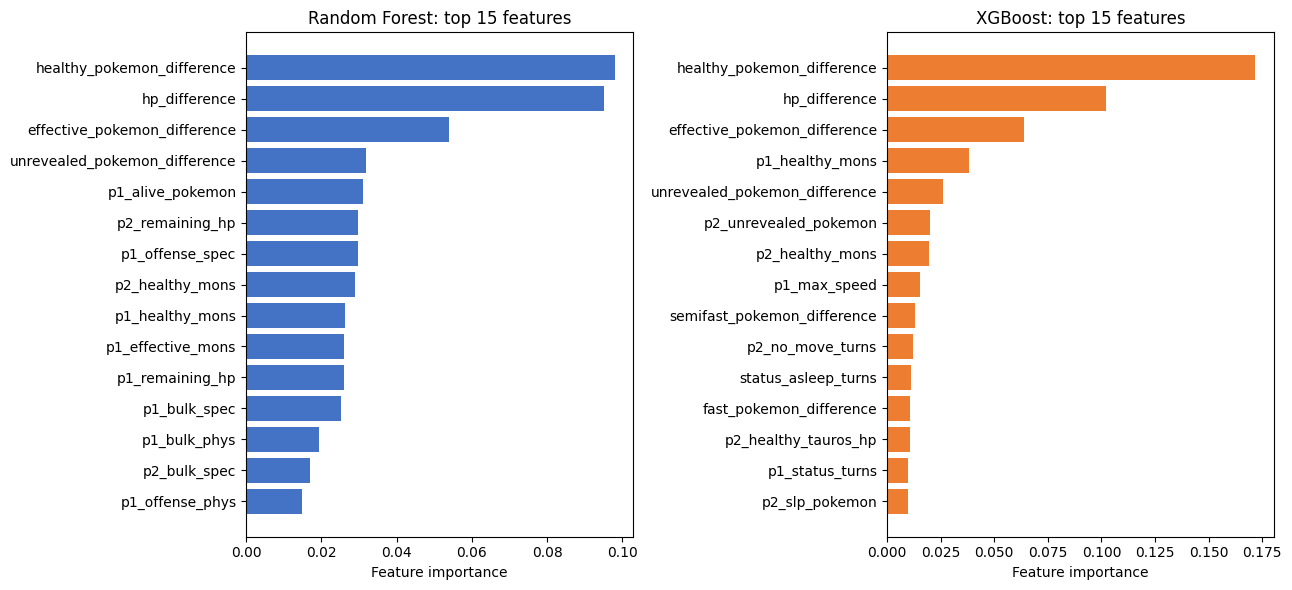

In [83]:
rf_importance = pd.Series(best_rf.feature_importances_, index=X.columns).nlargest(15).sort_values()
xgb_importance = pd.Series(best_xgb.feature_importances_, index=X.columns).nlargest(15).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

axes[0].barh(rf_importance.index, rf_importance.values, color="#4472C4")
axes[0].set_title("Random Forest: top 15 features")
axes[0].set_xlabel("Feature importance")

axes[1].barh(xgb_importance.index, xgb_importance.values, color="#ED7D31")
axes[1].set_title("XGBoost: top 15 features")
axes[1].set_xlabel("Feature importance")

fig.tight_layout()
plt.show()

## 8. Stacking ensemble and out-of-fold evaluation

The final classifier combines three base learners: scaled Logistic Regression, the tuned Random Forest, and the tuned XGBoost model. Their predictions are passed to a Logistic Regression meta-model, while `passthrough=True` also gives the meta-model access to the original engineered features.

Performance is estimated with an outer five-fold grouped cross-validation loop. For each fold, the full stack is fitted only on the training portion and evaluated on the held-out battles. We report the accuracy of every fold together with the mean and standard deviation, which show both expected performance and variability across splits.

In [84]:


estimators = [
    ("lr", make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000))),
    ("rf", best_rf),
    ("xgb", best_xgb),
]

meta_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=5000, random_state=42),
)

# Inner CV for the stacker (for meta-features): standard KFold
inner_cv = KFold(n_splits=5, shuffle=True, random_state=42)

stack_model = StackingClassifier(
    estimators=estimators,
    final_estimator=meta_model,
    cv=inner_cv,
    passthrough=True,
    n_jobs=-1,
)

# Outer CV for evaluation: GroupKFold (group-aware)
outer_cv = GroupKFold(n_splits=5)
fold_scores = []
stacking_cv_start = perf_counter()

for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X, y, groups), start=1):
    fold_start = perf_counter()
    print(f"[Stacking] Starting fold {fold}/{outer_cv.n_splits}...", flush=True)
    X_train, X_val = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[test_idx]

    stack_model.fit(X_train, y_train)
    preds = stack_model.predict(X_val)
    acc = accuracy_score(y_val, preds)
    fold_scores.append(acc)
    print(
        f"[Stacking] Fold {fold}/{outer_cv.n_splits} completed: "
        f"accuracy={acc:.4f}, elapsed={perf_counter() - fold_start:.1f}s.",
        flush=True,
    )

fold_scores = np.array(fold_scores)
print("\nStacking fold accuracies:", np.round(fold_scores, 4))
print(f"Mean CV accuracy: {fold_scores.mean():.4f} ± {fold_scores.std():.4f}")
print(
    f"[Stacking] Full cross-validation completed in "
    f"{perf_counter() - stacking_cv_start:.1f}s.",
    flush=True,
)


[Stacking] Starting fold 1/5...
[Stacking] Fold 1/5 completed: accuracy=0.8640, elapsed=68.1s.
[Stacking] Starting fold 2/5...
[Stacking] Fold 2/5 completed: accuracy=0.8615, elapsed=67.8s.
[Stacking] Starting fold 3/5...
[Stacking] Fold 3/5 completed: accuracy=0.8675, elapsed=68.1s.
[Stacking] Starting fold 4/5...
[Stacking] Fold 4/5 completed: accuracy=0.8450, elapsed=66.8s.
[Stacking] Starting fold 5/5...
[Stacking] Fold 5/5 completed: accuracy=0.8480, elapsed=68.2s.

Stacking fold accuracies: [0.864  0.8615 0.8675 0.845  0.848 ]
Mean CV accuracy: 0.8572 ± 0.0090
[Stacking] Full cross-validation completed in 339.2s.


### Cross-validation stability

The fold-level chart makes it easier to assess whether the mean accuracy is representative or driven by only one favorable split. The dashed line marks the average accuracy across the five held-out groups.

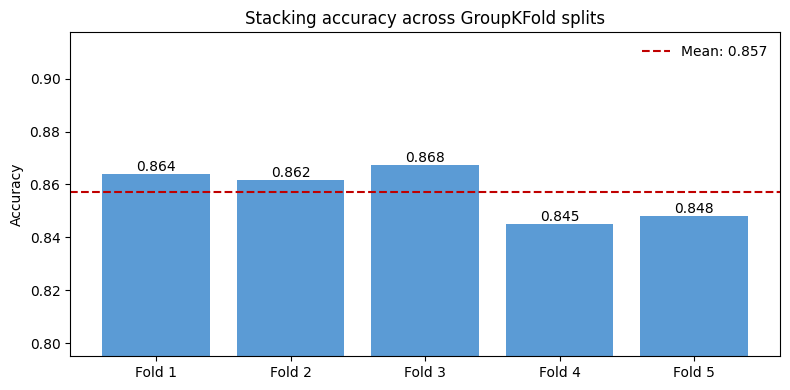

In [85]:
fold_labels = [f"Fold {index}" for index in range(1, len(fold_scores) + 1)]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(fold_labels, fold_scores, color="#5B9BD5")
ax.axhline(
    fold_scores.mean(),
    color="#C00000",
    linestyle="--",
    label=f"Mean: {fold_scores.mean():.3f}",
)
ax.set_title("Stacking accuracy across GroupKFold splits")
ax.set_ylabel("Accuracy")
ax.set_ylim(max(0, fold_scores.min() - 0.05), min(1, fold_scores.max() + 0.05))
ax.legend(frameon=False)

for bar, score in zip(bars, fold_scores):
    ax.text(bar.get_x() + bar.get_width() / 2, score, f"{score:.3f}", ha="center", va="bottom")

fig.tight_layout()
plt.show()

## 9. Sanity checks and feature inspection

As a lightweight diagnostic, we inspect the linear correlation between each numerical feature and the target. This is not a measure of feature importance for the nonlinear ensemble, but it can reveal unexpectedly strong relationships, constant columns, sign errors, or possible target leakage.

The table should therefore be interpreted as a debugging aid rather than as a causal explanation of battle outcomes.

In [86]:

pd.set_option("display.max_rows", None)

pd.set_option("display.max_colwidth", None)

pd.set_option("display.width", 0)

pd.set_option("display.float_format", lambda x: f"{x:.6f}")



### Target-correlation table

The display settings above make the complete diagnostic table readable. The next cell computes and prints the correlations, sorted by their absolute magnitude.

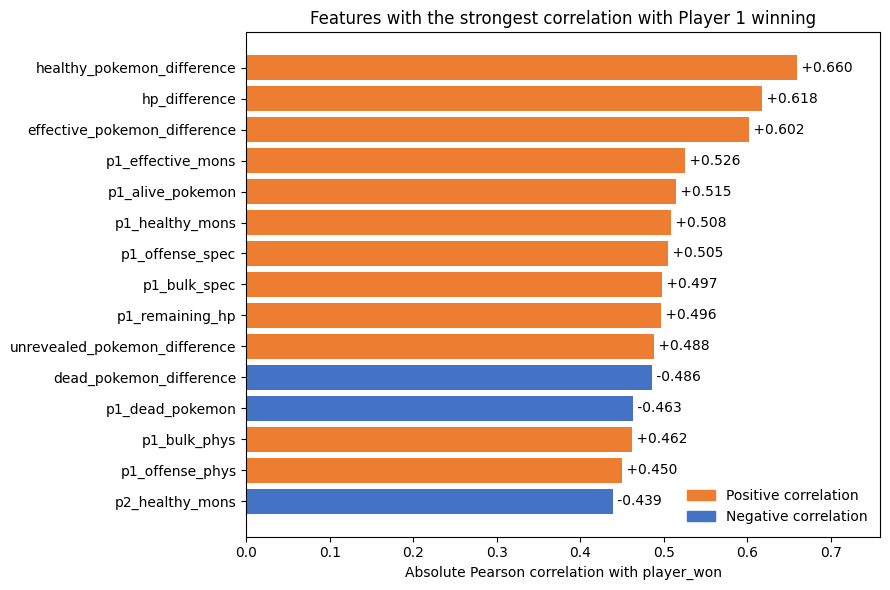

In [90]:
feature_correlations = (
    train_df.corr(numeric_only=True)["player_won"]
    .drop(labels=["player_won", "battle_id"], errors="ignore")
    .dropna()
)

top_features = feature_correlations.abs().nlargest(15).index
top_correlations = feature_correlations.loc[top_features]
plot_order = top_correlations.abs().sort_values().index

plot_values = top_correlations.loc[plot_order].abs()
colors = [
    "#4472C4" if top_correlations.loc[feature] < 0 else "#ED7D31"
    for feature in plot_order
]

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(plot_order, plot_values, color=colors)
ax.set_title("Features with the strongest correlation with Player 1 winning")
ax.set_xlabel("Absolute Pearson correlation with player_won")

for bar, feature in zip(bars, plot_order):
    signed_value = top_correlations.loc[feature]
    ax.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f" {signed_value:+.3f}",
        va="center",
    )

legend_handles = [
    plt.Rectangle((0, 0), 1, 1, color="#ED7D31", label="Positive correlation"),
    plt.Rectangle((0, 0), 1, 1, color="#4472C4", label="Negative correlation"),
]
ax.legend(handles=legend_handles, frameon=False, loc="lower right")
ax.set_xlim(0, plot_values.max() * 1.15)

fig.tight_layout()
plt.show()

## 10. Final training and submission

After evaluation, the stacking ensemble is refitted on the complete labeled dataset. Predictions for the test set are paired with their original `battle_id` values and exported to `submission.csv` in the format required by the challenge.

The generated file contains one row per test battle and two columns: `battle_id` and the predicted Boolean outcome `player_won`.

In [88]:

# Fit stacking model on all training data
final_fit_start = perf_counter()
print("[Final model] Fitting the stack on all training battles...", flush=True)
stack_model.fit(X, y)
print(
    f"[Final model] Training completed in "
    f"{perf_counter() - final_fit_start:.1f}s.",
    flush=True,
)



[Final model] Fitting the stack on all training battles...
[Final model] Training completed in 83.4s.


### Test-set prediction and export

The identifier is removed from the model inputs but retained for the output file. Predictions are then written in the same order as the test battles.

In [89]:
# Prepare test features (drop ID from model input)
X_test = test_df.drop(columns=["battle_id"], errors="ignore")

test_pred = stack_model.predict(X_test)

submission = pd.DataFrame({
    "battle_id": (
        test_df["battle_id"] if "battle_id" in test_df.columns else test_df.index
    ),
    "player_won": test_pred,
})

submission.to_csv("submission.csv", index=False)
print(f"\nsubmission.csv saved with {len(submission)} rows.")



submission.csv saved with 5000 rows.
